In [3]:
df = pd.read_csv("xauusd.csv")
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,04/23/2026,"4,747.50","4,744.99","4,770.40","4,700.24",98.37K,-0.12%
1,04/22/2026,"4,753.00","4,738.70","4,790.80","4,733.10",100.06K,0.71%
2,04/21/2026,"4,719.60","4,842.40","4,854.80","4,685.80",177.09K,-2.26%
3,04/20/2026,"4,828.80","4,811.80","4,847.90","4,752.00",123.21K,-1.04%
4,04/17/2026,"4,879.60","4,811.80","4,917.70","4,785.90",135.44K,1.48%


In [4]:
# Dataset clean
df.rename(columns={
    'Date': 'Time',
    'Price': 'Close',
    'Vol.': 'Volume'
}, inplace=True)

df.drop(columns=['Change %'], inplace=True)

# Converts price columns (removes commas)
for col in ['Open', 'High', 'Low', 'Close']:
    df[col] = df[col].astype(str).str.replace(',', '').astype(float)

# Converts volume (K, M → numbers)
def convert_volume(v):
    if isinstance(v, str):
        v = v.replace(',', '')
        if 'K' in v:
            return float(v.replace('K', '')) * 1000
        elif 'M' in v:
            return float(v.replace('M', '')) * 1000000
    return float(v)

df['Volume'] = df['Volume'].apply(convert_volume)

# Converts time
df['Time'] = pd.to_datetime(df['Time'])

# Sort data
df = df.sort_values(by='Time')

# Reset index
df.reset_index(drop=True, inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348 entries, 0 to 1347
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Time    1348 non-null   datetime64[ns]
 1   Close   1348 non-null   float64       
 2   Open    1348 non-null   float64       
 3   High    1348 non-null   float64       
 4   Low     1348 non-null   float64       
 5   Volume  1345 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 63.3 KB


In [5]:
df.dropna(inplace=True)

In [ ]:
## Adding Variables
# Range (volatility)
df['Range'] = df['High'] - df['Low']

# Body (candle strength)
df['Body'] = df['Close'] - df['Open']

# Direction (current candle)
df['Direction'] = (df['Close'] > df['Open']).astype(int)

# Moving Average (20)
df['MA20'] = df['Close'].rolling(window=20).mean()

df.head()

,Time,Close,Open,High,Low,Volume,Range,Body,Direction,MA20
0,2020-03-23,1567.6,1505.0,1569.3,1484.6,362070.0,84.7,62.6,1,NaN
1,2020-03-24,1660.8,1563.8,1698.0,1560.5,418780.0,137.5,97.0,1,NaN
2,2020-03-25,1633.4,1666.2,1699.3,1615.2,254190.0,84.1,-32.8,0,NaN
3,2020-03-26,1651.2,1642.5,1672.5,1611.0,215970.0,61.5,8.7,1,NaN
4,2020-03-27,1625.0,1640.4,1647.2,1611.4,100640.0,35.8,-15.4,0,NaN


In [7]:
## Final and important variable
# RSI (14)

delta = df['Close'].diff()

gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

rs = gain / loss

df['RSI'] = 100 - (100 / (1 + rs))

df.head()

,Time,Close,Open,High,Low,Volume,Range,Body,Direction,MA20,RSI
0,2020-03-23,1567.6,1505.0,1569.3,1484.6,362070.0,84.7,62.6,1,NaN,NaN
1,2020-03-24,1660.8,1563.8,1698.0,1560.5,418780.0,137.5,97.0,1,NaN,NaN
2,2020-03-25,1633.4,1666.2,1699.3,1615.2,254190.0,84.1,-32.8,0,NaN,NaN
3,2020-03-26,1651.2,1642.5,1672.5,1611.0,215970.0,61.5,8.7,1,NaN,NaN
4,2020-03-27,1625.0,1640.4,1647.2,1611.4,100640.0,35.8,-15.4,0,NaN,NaN


In [ ]:
# Fixing NaN values
df.dropna(inplace=True)

In [9]:
df.head()

,Time,Close,Open,High,Low,Volume,Range,Body,Direction,MA20,RSI
19,2020-04-20,1703.4,1685.0,1710.0,1677.6,620.0,32.4,18.4,1,1667.140,59.993970
20,2020-04-21,1678.3,1703.6,1709.9,1659.2,1660.0,50.7,-25.3,0,1672.675,64.401294
21,2020-04-22,1727.4,1698.6,1730.4,1690.1,1650.0,40.3,28.8,1,1676.005,70.303202
22,2020-04-23,1733.4,1725.6,1750.0,1721.2,1700.0,28.8,7.8,1,1681.005,66.442523
23,2020-04-24,1724.2,1733.7,1746.6,1715.0,900.0,31.6,-9.5,0,1684.655,63.763509


In [10]:
# Creating TARGET
df['Target'] = (df['Close'].shift(-1) > df['Open'].shift(-1)).astype(int)

# remove last row (it becomes NaN after shift)
df.dropna(inplace=True)

df.head()

,Time,Close,Open,High,Low,Volume,Range,Body,Direction,MA20,RSI,Target
19,2020-04-20,1703.4,1685.0,1710.0,1677.6,620.0,32.4,18.4,1,1667.140,59.993970,0
20,2020-04-21,1678.3,1703.6,1709.9,1659.2,1660.0,50.7,-25.3,0,1672.675,64.401294,1
21,2020-04-22,1727.4,1698.6,1730.4,1690.1,1650.0,40.3,28.8,1,1676.005,70.303202,1
22,2020-04-23,1733.4,1725.6,1750.0,1721.2,1700.0,28.8,7.8,1,1681.005,66.442523,0
23,2020-04-24,1724.2,1733.7,1746.6,1715.0,900.0,31.6,-9.5,0,1684.655,63.763509,0


In [11]:
# Building the model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Features (inputs)
X = df[['Range', 'Body', 'Direction', 'MA20', 'RSI']]

# Target (output)
y = df['Target']

# Split data (train/test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, predictions))

Accuracy: 0.5263157894736842
Confusion Matrix:
 [[  1 123]
 [  3 139]]


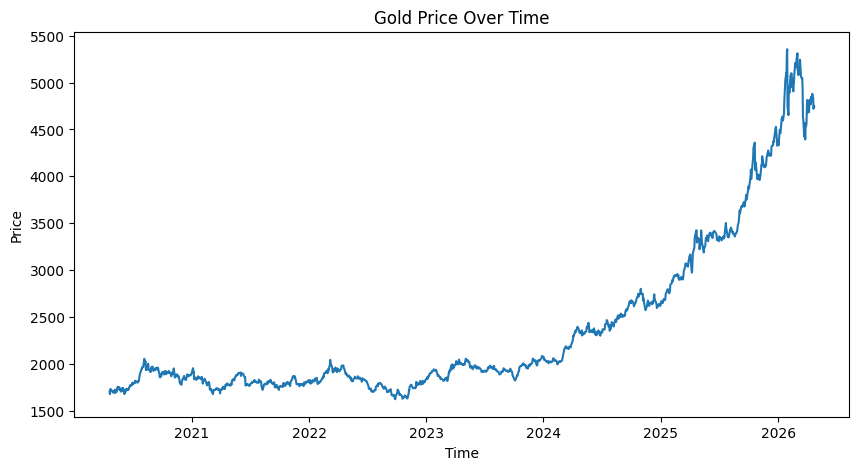

In [12]:
# Price Chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Time'], df['Close'])
plt.title("Gold Price Over Time")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

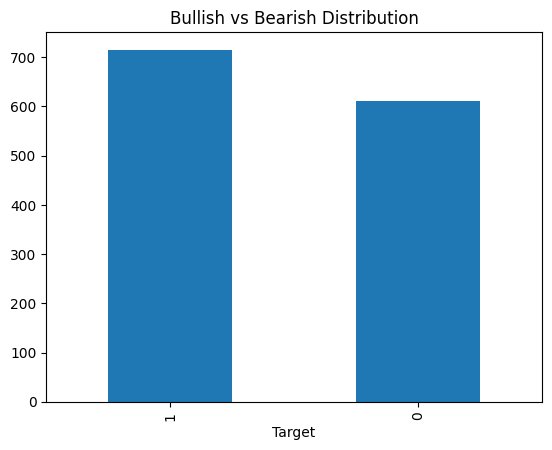

In [13]:
# Target Distribution
df['Target'].value_counts().plot(kind='bar')
plt.title("Bullish vs Bearish Distribution")
plt.show()

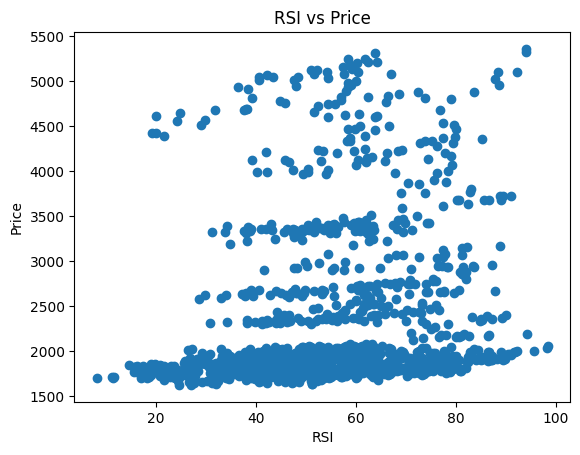

In [14]:
# RSI vs Price 
plt.scatter(df['RSI'], df['Close'])
plt.title("RSI vs Price")
plt.xlabel("RSI")
plt.ylabel("Price")
plt.show()

# Analysis of Gold (XAUUSD) Market Behavior

1. Problem Definition
The objective of this project is to analyze historical gold price data and predict the direction of the next price movement using a classification model.

2. Dataset Description
The dataset was collected from Investing.com and contains approximately 1300 observations. It includes variables such as open, high, low, close prices and trading volume.

3. Data Cleaning
The dataset was cleaned by removing missing values, converting data types, and formatting columns to ensure consistency.

4. Feature Engineering
New variables were created including:
- Range (volatility)
- Body (price movement strength)
- Direction (bullish/bearish)
- Moving Average (trend)
- RSI (momentum)

5. Model
A logistic regression model was used to classify whether the next price movement is bullish or bearish.

6. Results
The model achieved an accuracy of approximately 52%. This indicates limited predictive power due to the complexity of financial markets.

7. Conclusion
The analysis shows that while some patterns exist, predicting financial markets remains challenging. Future improvements could include more advanced models and additional features.
